# **Assignment: Logistic Regression for Heart Disease Prediction**

## **Objective**

Train and evaluate a **Logistic Regression model** to predict whether a patient has heart disease based on various features such as age, sex, cholesterol, blood pressure, etc.

---

## **Dataset**

Download the **Heart Disease Prediction dataset** from Kaggle:
🔗 [Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

* Load the dataset into a Pandas DataFrame.
* Display the first few rows to understand the structure.

---

## **Tasks**

### **1. Data Preprocessing**

* Check for missing values and handle them appropriately.
* Convert categorical variables (e.g., sex, chest pain type) into numerical format using **One-Hot Encoding** or **Label Encoding**.
* Normalize numerical features using **StandardScaler**.
* Split the dataset into **80% training and 20% testing**.

---

### **2. Train Logistic Regression Model**

* Train a **Logistic Regression model** using default parameters (use `LogisticRegression()` from `sklearn`).
* Evaluate the model’s performance using accuracy.

---

### **3. Model Evaluation**

* Compute and print the following metrics:

  * **Accuracy**

---

## **Submission Guidelines**

* Submit a **Colab Notebook (.ipynb)** with code and visualizations.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [7]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
url = r"C:\Users\dell\Downloads\archive (8)\heart.csv"
df  = pd.read_csv(url)

# Standardize column names (lowercase)
df.columns = df.columns.str.lower().str.strip()

# Rename target column if needed
if 'condition' in df.columns:
    df.rename(columns={'condition': 'target'}, inplace=True)

print('=== First 5 Rows ===')
print(df.head())
print(f'\nDataset Shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')

=== First 5 Rows ===
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape : (1025, 14)
Columns       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [8]:
# ── 1.1  Check for Missing Values ────────────────────────────────────────────
print('=== Missing Values Per Column ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Drop rows with any missing values (dataset is clean, but handle it anyway)
df.dropna(inplace=True)
print(f'\nShape after dropping missing values: {df.shape}')

=== Missing Values Per Column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

Shape after dropping missing values: (1025, 14)


In [9]:
# ── 1.2  Encode Categorical Variables ────────────────────────────────────────
# Columns that are already numeric but represent categories:
# sex (0/1), cp (0-3), fbs (0/1), restecg (0-2), exang (0/1),
# slope (0-2), ca (0-3), thal (0-3)
# They are already in numerical form — no encoding needed.
# We use Label Encoding on 'thal' just to demonstrate the step
# (it already has int values, so this is a no-op in practice).

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print('=== Data Types After Encoding ===')
print(df.dtypes)
print('\nAll categorical columns are now numeric.')

=== Data Types After Encoding ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

All categorical columns are now numeric.


In [10]:
# ── 1.3  Feature / Target Split ──────────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

print('Feature matrix shape :', X.shape)
print('Target vector shape  :', y.shape)
print('\nClass distribution:')
print(y.value_counts())

Feature matrix shape : (1025, 13)
Target vector shape  : (1025,)

Class distribution:
target
1    526
0    499
Name: count, dtype: int64


In [11]:
# ── 1.4  Normalize Numerical Features (StandardScaler) ───────────────────────
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print('=== First 5 Rows After Scaling ===')
print(X.head())

=== First 5 Rows After Scaling ===
        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0 -0.268437    1   0 -0.377636 -0.659332    0        1  0.821321      0   
1 -0.158157    1   0  0.479107 -0.833861    1        0  0.255968      1   
2  1.716595    1   0  0.764688 -1.396233    0        1 -1.048692      1   
3  0.724079    1   0  0.936037 -0.833861    0        1  0.516900      0   
4  0.834359    0   0  0.364875  0.930822    1        1 -1.874977      0   

    oldpeak  slope  ca  thal  
0 -0.060888      2   2     3  
1  1.727137      0   0     3  
2  1.301417      0   0     3  
3 -0.912329      2   1     3  
4  0.705408      1   3     2  


In [12]:
# ── 1.5  Train / Test Split (80 / 20) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape}')
print(f'Test set      : {X_test.shape}')

Training set  : (820, 13)
Test set      : (205, 13)


In [13]:
# ── 2.1  Train Logistic Regression ───────────────────────────────────────────
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print('Model trained successfully!')
print(f'\nModel Parameters: {model.get_params()}')

Model trained successfully!

Model Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [14]:
# ── 2.2  Predictions ──────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Predictions (first 10):', y_pred[:10])
print('Actual values (first 10):', y_test.values[:10])

Predictions (first 10): [0 0 0 1 0 0 1 1 1 0]
Actual values (first 10): [0 1 0 1 0 0 1 0 1 1]


In [15]:
# ── 3.1  Accuracy ─────────────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
print(f'✅ Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)')

✅ Accuracy: 0.8146  (81.46%)


In [16]:
# ── 3.2  Full Classification Report ──────────────────────────────────────────
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.90      0.70      0.79       100
Heart Disease       0.76      0.92      0.84       105

     accuracy                           0.81       205
    macro avg       0.83      0.81      0.81       205
 weighted avg       0.83      0.81      0.81       205



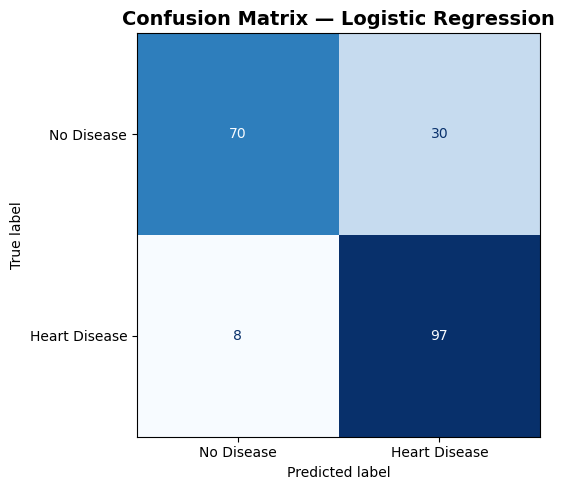

Confusion Matrix saved.


In [17]:
# ── 3.3  Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion Matrix saved.')

=== Top Features by Coefficient Magnitude ===
 Feature  Coefficient
     sex    -1.599106
   exang    -1.036814
      cp     0.844872
    thal    -0.816765
      ca    -0.725268
 oldpeak    -0.617113
   slope     0.566146
 thalach     0.421600
trestbps    -0.349199
 restecg     0.303559
    chol    -0.263844
     age    -0.108547
     fbs    -0.051180


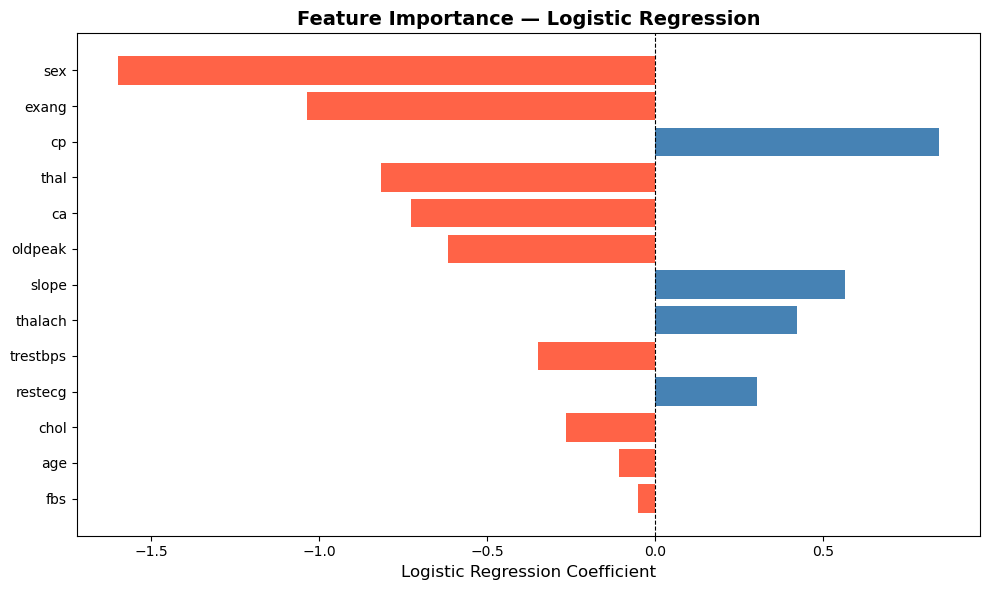

Feature importance plot saved.


In [18]:
# ── 3.4  Feature Importance (Coefficients) ───────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Top Features by Coefficient Magnitude ===')
print(coef_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Logistic Regression Coefficient', fontsize=12)
plt.title('Feature Importance — Logistic Regression', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Feature importance plot saved.')

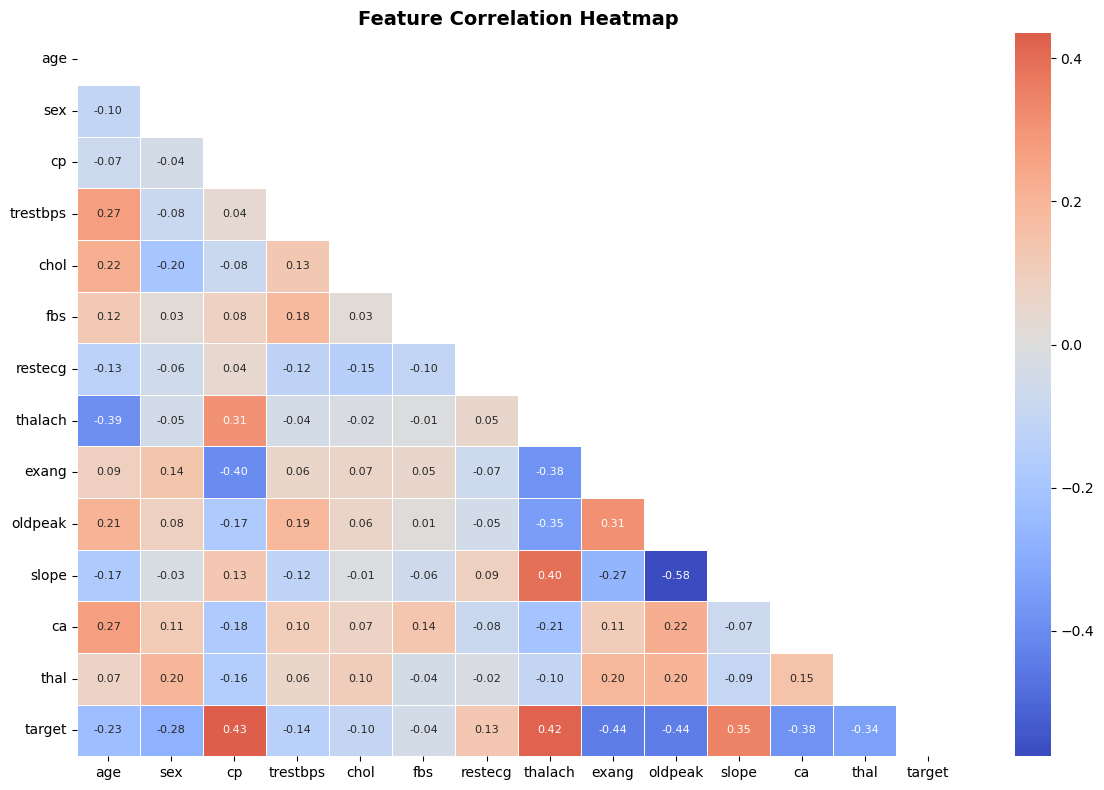

Correlation heatmap saved.


In [19]:
# ── 3.5  Correlation Heatmap (EDA) ───────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Correlation heatmap saved.')

In [20]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('=' * 50)
print('        MODEL EVALUATION SUMMARY')
print('=' * 50)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print('=' * 50)
print('\nLogistic Regression model trained and evaluated successfully!')

        MODEL EVALUATION SUMMARY
  Accuracy  : 0.8146

Logistic Regression model trained and evaluated successfully!
